In [ ]:
''' ESSAY EVALUATION WORKFLOW 
     This workflow evaluates an essay on multiple dimensions in parallel and aggregates the feedback. 
     BASED ON CLARITY, LANGUAGE QUALITY, AND DEPTH OF ANALYSIS. 
     PROVIDE STRUCTURED FEEDBACK AND SCORES FOR EACH DIMENSION. 
     FINALLY PROVIDES AN OVERALL ASSESSMENT OF THE ESSAY USING THE AGGREGATED FEEDBACK AND SCORES '''

In [25]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os

# Load environment variables from .env file
load_dotenv()

llm = ChatOpenAI(model="moonshotai/kimi-k2-instruct-0905", temperature=0.7, api_key=os.getenv("GROQ_API_KEY"), base_url=os.getenv("GROQ_BASE_URL"))


In [26]:
from pydantic import BaseModel, Field

class EvaluationSchema(BaseModel):
    
    feedback: str = Field(..., description="Feedback on the quality of the answer.")
    score: int = Field(..., description="A score from 1 to 10 evaluating the answer.")

structured_model = llm.with_structured_output(EvaluationSchema)


In [45]:
from typing import Annotated, TypedDict
import operator

class EssayState(TypedDict):
    
    essay: str
    clarity_feedback: str
    language_feedback: str
    depth_feedback: str

    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add]
    overall_score: int = Field(..., description="An overall score from 1 to 10 evaluating the essay.")
    

In [46]:
def clarity_feedback(state: EssayState):
    prompt = f"Provide feedback on the clarity of the following essay:\n\n{state['essay']}"

    output = structured_model.invoke(prompt)

    return {
        'clarity_feedback': output.feedback,
        'individual_scores': [output.score]
    }

In [47]:
def language_feedback(state: EssayState):
    prompt = f"Provide feedback on the language quality of the following essay:\n\n{state['essay']}"

    output = structured_model.invoke(prompt)

    return {
        'language_feedback': output.feedback,
        'individual_scores': [output.score]
    }

In [48]:
def depth_feedback(state: EssayState):
    prompt = f"Provide feedback on the depth of analysis in the following essay:\n\n{state['essay']}"

    output = structured_model.invoke(prompt)

    return {
        'depth_feedback': output.feedback,
        'individual_scores': [output.score]
    }

In [49]:
def overall_feedback(state: EssayState):
    prompt = f"Based on the following essay and feedback, provide overall feedback and an overall score:\n\nClarity Feedback:\n{state['clarity_feedback']}\n\nLanguage Feedback:\n{state['language_feedback']}\n\nDepth Feedback:\n{state['depth_feedback']}"

    output = llm.invoke(prompt).content

    overall_score = sum(state['individual_scores']) // len(state['individual_scores'])

    return {
        'overall_feedback': output,
        'overall_score': overall_score
    }

In [50]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(EssayState)

# Define the nodes
graph.add_node('clarity_feedback', clarity_feedback)
graph.add_node('language_feedback', language_feedback)
graph.add_node('depth_feedback', depth_feedback)
graph.add_node('overall_feedback', overall_feedback)

# Define the edges parallel feedback nodes
graph.add_edge(START, 'clarity_feedback')
graph.add_edge(START, 'language_feedback')
graph.add_edge(START, 'depth_feedback')

# Define the edge from feedback nodes to overall feedback node
graph.add_edge('clarity_feedback', 'overall_feedback')
graph.add_edge('language_feedback', 'overall_feedback')
graph.add_edge('depth_feedback', 'overall_feedback')

# Define the edge from overall feedback node to END
graph.add_edge('overall_feedback', END)

# Compile the graph into a workflow
workflow = graph.compile()


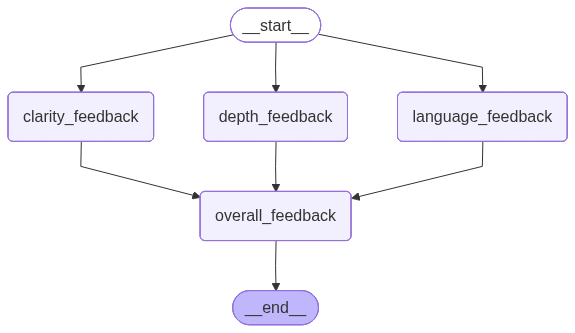

In [51]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())


In [52]:
inital_state = {'essay': "The future of AI in healthcare is promising, with advancements in machine learning and data analytics leading to improved diagnostics and personalized treatment plans. However, ethical considerations and data privacy concerns must be addressed to ensure responsible implementation."}
final_state = workflow.invoke(inital_state)

for key, value in final_state.items():
    print(f"{key}: {value}\n")

essay: The future of AI in healthcare is promising, with advancements in machine learning and data analytics leading to improved diagnostics and personalized treatment plans. However, ethical considerations and data privacy concerns must be addressed to ensure responsible implementation.

clarity_feedback: The paragraph is concise and logically sequenced, but its clarity is limited by the use of broad, catch-all phrases (“promising,” “ethical considerations,” “data privacy concerns”) that are never unpacked for the reader. Without concrete examples—such as a specific diagnostic tool or a data-privacy regulation—the audience is left to guess what the challenges actually look like, which mutes the persuasive force of the argument. Additionally, the single-sentence treatment of ethics versus diagnostics feels abrupt; a transition explaining how privacy risks directly affect the reliability of AI diagnoses would tighten the flow. Overall, the writing is grammatically clean and free of jarg